In [ ]:
!pip install tensorflow

# Mount colab with drive

In [7]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


### 2. Set dataset paths

In [40]:
train_dir="/content/drive/MyDrive/Colab Notebooks/Medical image/dataset/Training"
test_dir="/content/drive/MyDrive/Colab Notebooks/Medical image/dataset/Testing"

### 3.Python Libraries Import

In [41]:
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50, DenseNet121
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Flatten, Activation ,Dropout, GlobalAveragePooling2D,Input
from tensorflow.keras.optimizers import Adam
import os

### input size

In [42]:
img_size = (224, 224)
batch_size = 32

### Preprocess images of traning data

In [43]:
from tensorflow.keras.applications.densenet import preprocess_input
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,           # Increased
    width_shift_range=0.2,       # Increased
    height_shift_range=0.2,      # Increased
    shear_range=0.15,            # NEW - helps with overfitting
    zoom_range=0.2,              # Increased
    horizontal_flip=True,
    vertical_flip=True,          # NEW - medical images can be flipped vertically
    fill_mode='nearest',
    validation_split=0.2
)

### Testing data generator


In [44]:
from tensorflow.keras.applications.densenet import preprocess_input
test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

### traning data generation

In [45]:
train_data=train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,  # by default it takes rgb colo image
    batch_size=32,
    color_mode='rgb',
    class_mode='categorical',
    subset='training',
    shuffle=True
)

Found 2297 images belonging to 4 classes.


### Validation generator

In [46]:
valid_data=train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 573 images belonging to 4 classes.


### test data generation

In [47]:
test_data=test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=32,
    class_mode='categorical'

)

Found 394 images belonging to 4 classes.


check imbelance

In [48]:
print(train_data.class_indices)
print(train_data.classes)

{'glioma_tumor': 0, 'meningioma_tumor': 1, 'no_tumor': 2, 'pituitary_tumor': 3}
[0 0 0 ... 3 3 3]


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_data.classes),
    y=train_data.classes
)

class_weights = dict(enumerate(class_weights))
print(class_weights)


{0: np.float64(0.8687594553706506), 1: np.float64(0.8727203647416414), 2: np.float64(1.817246835443038), 3: np.float64(0.8674471299093656)}


### load pretrain resnet50 model

In [ ]:
base_model=DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)
# freeze  all layer of resnet base model
for layers in base_model.layers:
    layers.trainable=False

### freeze classification layers

In [ ]:
# Unfreeze last 20 layers (gradual unfreezing helps)
for layer in base_model.layers[-20:]:
    layer.trainable = True

# for layer in base_model.layers[-10:]:
 #    layer.trainable = True

### custom Classification model

In [ ]:
X_batch, y_batch = next(train_data)
print(X_batch)

[[[[-2.0122755  -1.927728   -1.6969382 ]
   [-2.032018   -1.947911   -1.7170315 ]
   [-2.0237656  -1.9394746  -1.7086325 ]
   ...
   [-2.0236917  -1.9393989  -1.7085571 ]
   [-2.0251322  -1.9408717  -1.7100234 ]
   [-2.026573   -1.9423444  -1.7114897 ]]

  [[-2.0075526  -1.9228995  -1.6921312 ]
   [-2.0116432  -1.9270815  -1.6962944 ]
   [-2.0239003  -1.9396123  -1.7087696 ]
   ...
   [-2.0151556  -1.9306722  -1.6998693 ]
   [-2.0151556  -1.9306722  -1.6998693 ]
   [-2.0151556  -1.9306722  -1.6998693 ]]

  [[-1.9951597  -1.9102302  -1.6795181 ]
   [-2.0019054  -1.9171265  -1.6863838 ]
   [-2.0163016  -1.9318441  -1.701036  ]
   ...
   [-2.0168588  -1.9324136  -1.7016028 ]
   [-2.015418   -1.9309407  -1.7001365 ]
   [-2.0151556  -1.9306722  -1.6998693 ]]

  ...

  [[-2.117904   -2.0357141  -1.8044444 ]
   [-2.117904   -2.0357141  -1.8044444 ]
   [-2.117904   -2.0357141  -1.8044444 ]
   ...
   [-2.0836544  -2.0007002  -1.7695861 ]
   [-2.0836544  -2.0007002  -1.7695861 ]
   [-2.0836544  

# CUSTOME LAYERS

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2

# Build simpler model
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu', kernel_regularizer=l2(0.01))(x)  # Added L2 regularization
x = Dropout(0.6)(x)  # Increased dropout
x = Dense(64, activation='relu', kernel_regularizer=l2(0.01))(x)   # Smaller layer
x = Dropout(0.5)(x)
output = Dense(4, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)


# compile model
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',      # my model is hot encoding formate [1 0 0 0]
    metrics=['accuracy']
)


In [ ]:
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_4    │ (None, 230, 230,  │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d_4… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_5    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_5… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 7,177,220 (27.38 MB)

 Trainable params: 506,884 (1.93 MB)

 Non-trainable params: 6,670,336 (25.45 MB)

call backs

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,           # Stop if no improvement for 10 epochs
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,            # Reduce learning rate by half
        patience=5,            # Wait 5 epochs before reducing
        min_lr=0.000001        # Minimum learning rate
    ),
    ModelCheckpoint(
        'best_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max'
    )
]

### train data

In [ ]:
'''
history=model.fit(
    train_data,
    validation_data=valid_data,
    epochs=10
)
'''
history = model.fit(
    train_data,
    steps_per_epoch=len(train_data),
    validation_data=valid_data,
    validation_steps=len(valid_data),
    epochs=50,  # Increased epochs
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.2369 - loss: 5.1065

72/72 ━━━━━━━━━━━━━━━━━━━━ 441s 6s/step - accuracy: 0.2375 - loss: 5.1017 - val_accuracy: 0.3508 - val_loss: 4.1154 - learning_rate: 1.0000e-04
Epoch 2/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.3153 - loss: 4.1378

72/72 ━━━━━━━━━━━━━━━━━━━━ 432s 6s/step - accuracy: 0.3158 - loss: 4.1362 - val_accuracy: 0.5044 - val_loss: 3.7271 - learning_rate: 1.0000e-04
Epoch 3/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.4225 - loss: 3.7320

72/72 ━━━━━━━━━━━━━━━━━━━━ 445s 6s/step - accuracy: 0.4229 - loss: 3.7307 - val_accuracy: 0.5846 - val_loss: 3.4243 - learning_rate: 1.0000e-04
Epoch 4/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.4873 - loss: 3.4213

...

72/72 ━━━━━━━━━━━━━━━━━━━━ 450s 6s/step - accuracy: 0.9103 - loss: 1.2428 - val_accuracy: 0.8901 - val_loss: 1.2939 - learning_rate: 1.0000e-04
Epoch 29/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9152 - loss: 1.1978

72/72 ━━━━━━━━━━━━━━━━━━━━ 495s 7s/step - accuracy: 0.9152 - loss: 1.1977 - val_accuracy: 0.8935 - val_loss: 1.2690 - learning_rate: 1.0000e-04
Epoch 30/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 422s 6s/step - accuracy: 0.9213 - loss: 1.1749 - val_accuracy: 0.8778 - val_loss: 1.2927 - learning_rate: 1.0000e-04
Epoch 31/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 433s 6s/step - accuracy: 0.9300 - loss: 1.1138 - val_accuracy: 0.8901 - val_loss: 1.2556 - learning_rate: 1.0000e-04
Epoch 32/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9078 - loss: 1.1243

72/72 ━━━━━━━━━━━━━━━━━━━━ 422s 6s/step - accuracy: 0.9079 - loss: 1.1240 - val_accuracy: 0.8953 - val_loss: 1.2217 - learning_rate: 1.0000e-04
Epoch 33/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 435s 6s/step - accuracy: 0.9179 - loss: 1.0888 - val_accuracy: 0.8813 - val_loss: 1.1954 - learning_rate: 1.0000e-04
Epoch 34/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 429s 6s/step - accuracy: 0.9351 - loss: 1.0222 - val_accuracy: 0.8743 - val_loss: 1.2194 - learning_rate: 1.0000e-04
Epoch 35/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 433s 6s/step - accuracy: 0.9239 - loss: 1.0229 - val_accuracy: 0.8813 - val_loss: 1.2163 - learning_rate: 1.0000e-04
Epoch 36/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 435s 6s/step - accuracy: 0.9399 - loss: 0.9598 - val_accuracy: 0.8901 - val_loss: 1.0886 - learning_rate: 1.0000e-04
Epoch 37/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9435 - loss: 0.9476

72/72 ━━━━━━━━━━━━━━━━━━━━ 412s 6s/step - accuracy: 0.9434 - loss: 0.9475 - val_accuracy: 0.8970 - val_loss: 1.1444 - learning_rate: 1.0000e-04
Epoch 38/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 444s 6s/step - accuracy: 0.9519 - loss: 0.9068 - val_accuracy: 0.8813 - val_loss: 1.1304 - learning_rate: 1.0000e-04
Epoch 39/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 394s 5s/step - accuracy: 0.9393 - loss: 0.9189 - val_accuracy: 0.8935 - val_loss: 1.0236 - learning_rate: 1.0000e-04
Epoch 40/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 432s 5s/step - accuracy: 0.9495 - loss: 0.8488 - val_accuracy: 0.8953 - val_loss: 1.0190 - learning_rate: 1.0000e-04
Epoch 41/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 445s 5s/step - accuracy: 0.9527 - loss: 0.8250 - val_accuracy: 0.8621 - val_loss: 1.0971 - learning_rate: 1.0000e-04
Epoch 42/50
42/72 ━━━━━━━━━━━━━━━━━━━━ 2:11 4s/step - accuracy: 0.9541 - loss: 0.8114

KeyboardInterrupt: 

In [ ]:
#model.save("/content/drive/MyDrive/Colab Notebooks/tumor_dens_noft_expo4.keras")

model.save("/content/drive/MyDrive/Colab Notebooks/tumor_dens78.keras")


### model evalution

In [ ]:
test_loss, test_acc = model.evaluate(test_data)
print("Test Accuracy:", test_acc)


13/13 ━━━━━━━━━━━━━━━━━━━━ 49s 4s/step - accuracy: 0.7572 - loss: 1.9463
Test Accuracy: 0.7868020534515381


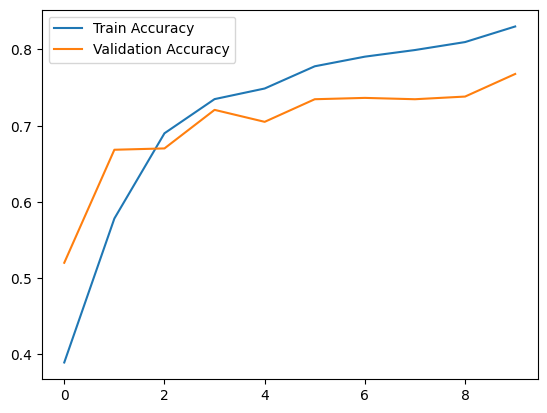

In [ ]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.show()


get true label and prediction

In [15]:

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns


# Reset generator (VERY IMPORTANT)
test_data.reset()

# Predict probabilities
y_pred_probs = model.predict(test_data, verbose=1)

# Convert probabilities → class labels
y_pred = np.argmax(y_pred_probs, axis=1)

# True labels
y_true = test_data.classes

# Class names
class_names = list(test_data.class_indices.keys())



NameError: name 'model' is not defined

visualization

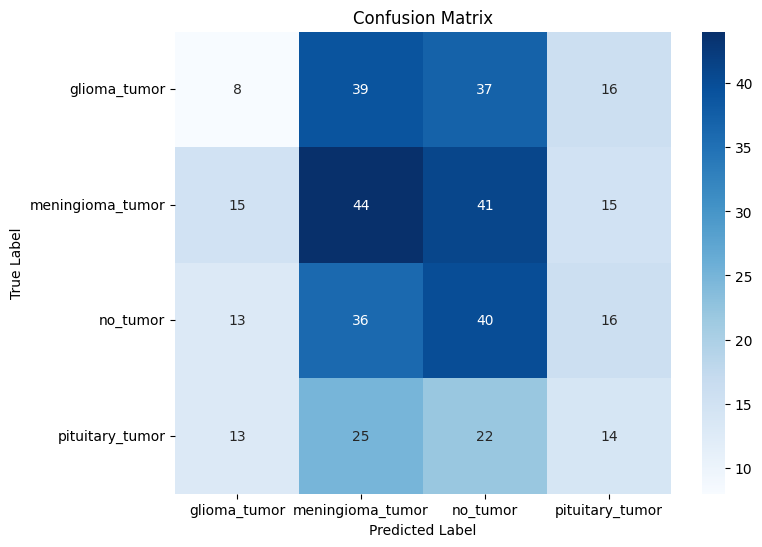

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


classification report

In [ ]:
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names
)

print("Classification Report:\n")
print(report)


Classification Report:

                  precision    recall  f1-score   support

    glioma_tumor       0.16      0.08      0.11       100
meningioma_tumor       0.31      0.38      0.34       115
        no_tumor       0.29      0.38      0.33       105
 pituitary_tumor       0.23      0.19      0.21        74

        accuracy                           0.27       394
       macro avg       0.25      0.26      0.25       394
    weighted avg       0.25      0.27      0.25       394



🔹 STEP 4: Resume training from correct epoch

👉 If you trained 10 epochs already, resume from epoch 10

In [ ]:
from sklearn.metrics import confusion_matrix
# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Row-wise normalization (per true class)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]


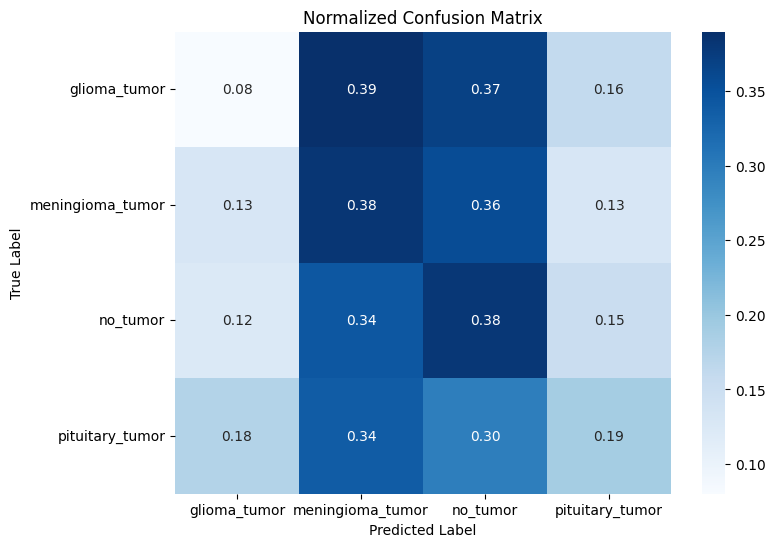

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Normalized Confusion Matrix")
plt.show()


In [ ]:
test_loss, test_acc = model.evaluate(test_data)
print("Test Accuracy:", test_acc)


13/13 ━━━━━━━━━━━━━━━━━━━━ 68s 5s/step - accuracy: 0.5752 - loss: 1.3544
Test Accuracy: 0.5736040472984314


In [20]:
from tensorflow.keras.models import load_model

# Load the model
model = load_model('/content/best_model (1).h5')

KeyError: 'Unable to synchronously open object (bad heap free list)'

In [23]:

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns


# Reset generator (VERY IMPORTANT)
test_data.reset()

# Predict probabilities
y_pred_probs = model.predict(test_data, verbose=1)

# Convert probabilities → class labels
y_pred = np.argmax(y_pred_probs, axis=1)

# True labels
y_true = test_data.classes

# Class names
class_names = list(test_data.class_indices.keys())



13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 325ms/step


In [29]:
from sklearn.metrics import confusion_matrix
import numpy as np

cm = confusion_matrix(y_true, y_pred)
per_class_accuracy = cm.diagonal() / cm.sum(axis=1) * 100

for i, acc in enumerate(per_class_accuracy):
    print(f"Class {i} ({list(train_data.class_indices.keys())[i]}): {acc:.1f}%")

Class 0 (glioma_tumor): 14.0%
Class 1 (meningioma_tumor): 37.4%
Class 2 (no_tumor): 28.6%
Class 3 (pituitary_tumor): 14.9%


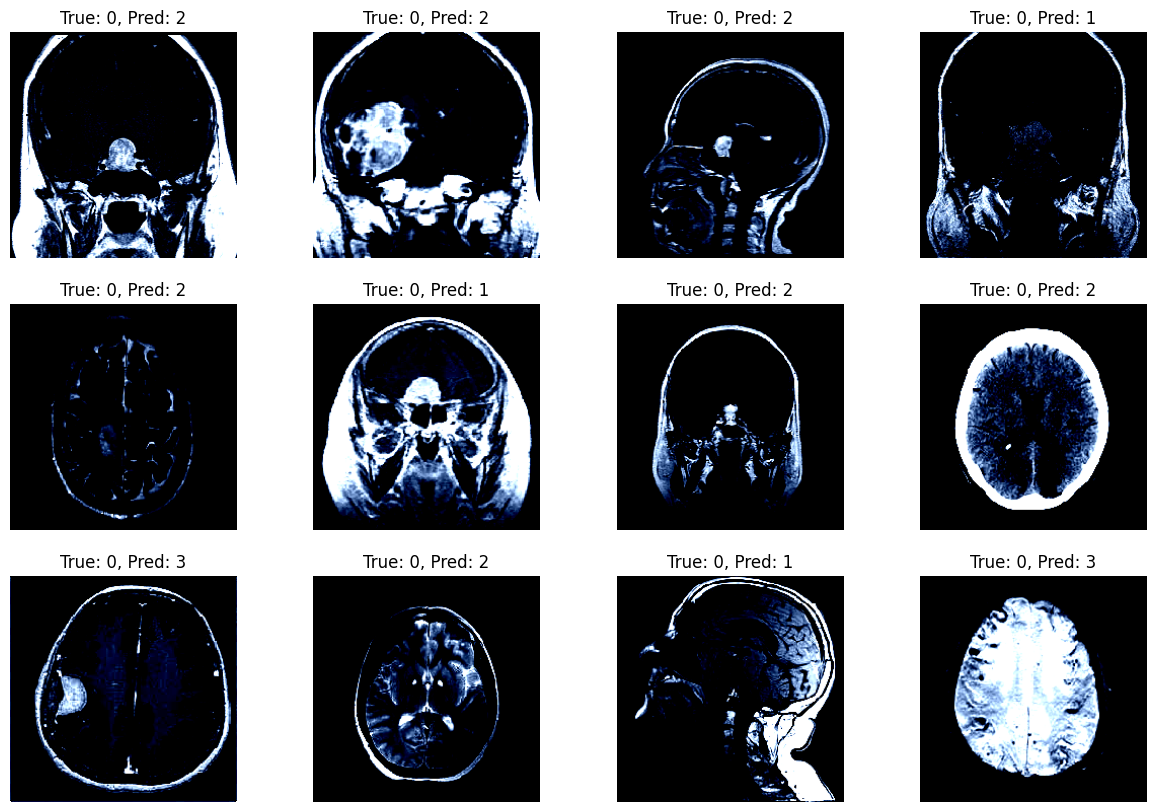

In [31]:
import matplotlib.pyplot as plt

# Show some misclassified examples
misclassified_idx = np.where(y_pred != y_true)[0]

plt.figure(figsize=(15, 10))
for i, idx in enumerate(misclassified_idx[:12]):
    plt.subplot(3, 4, i+1)
    # Get the image (you'll need to load it properly)
    img = test_data[0][0][i]  # Adjust based on your data structure
    plt.imshow(img)
    true_label = y_true[idx]
    pred_label = y_pred[idx]
    plt.title(f"True: {true_label}, Pred: {pred_label}")
    plt.axis('off')
plt.show()

In [52]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import itertools

# Assuming you have your trained model
model = ...  # Your trained model

# Define your test data generator (NO augmentation for test!)
test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input  # Same preprocessing as training
)

test_generator = test_datagen.flow_from_directory(
    directory='/content/drive/MyDrive/Colab Notebooks/Medical image/dataset/Testing',
    target_size=(224, 224),  # Same as training
    batch_size=32,
    class_mode='categorical',
    shuffle=False,  # IMPORTANT: Don't shuffle for evaluation
    seed=42
)

# Get class names from generator
class_names = list(test_generator.class_indices.keys())
print(f"Class names: {class_names}")
print(f"Number of test samples: {test_generator.samples}")

# Method 1: Predict on entire test set
print("\n=== Making Predictions ===")
test_generator.reset()  # Reset generator to start from beginning
y_pred_probs = model.predict(test_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)

# Get true labels
y_true = test_generator.classes

# Method 2: Alternative with more control
def get_predictions_and_labels(model, generator):
    """Get predictions and labels with batch-by-batch control"""
    generator.reset()
    all_preds = []
    all_labels = []

    for i in range(len(generator)):
        if i % 10 == 0:
            print(f"Processing batch {i+1}/{len(generator)}")

        images, labels = generator[i]
        preds = model.predict(images, verbose=0)
        batch_preds = np.argmax(preds, axis=1)
        batch_labels = np.argmax(labels, axis=1)

        all_preds.extend(batch_preds)
        all_labels.extend(batch_labels)

    return np.array(all_preds), np.array(all_labels)

# Uncomment if you want batch-by-batch control
# y_pred, y_true = get_predictions_and_labels(model, test_generator)

# Calculate confusion matrix
cm = confusion_matrix(y_true, y_pred)
print(f"\nConfusion Matrix Shape: {cm.shape}")

# Visualize confusion matrix
def plot_confusion_matrix(cm, class_names, normalize=False, title='Confusion Matrix'):
    """
    Plots confusion matrix as a heatmap
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        fmt = '.2f'
        vmin, vmax = 0, 1
        title = 'Normalized ' + title
    else:
        fmt = 'd'
        vmin, vmax = None, None

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names,
                vmin=vmin, vmax=vmax)

    plt.title(title, fontsize=16, pad=20)
    plt.ylabel('True Label', fontsize=14)
    plt.xlabel('Predicted Label', fontsize=14)
    plt.tight_layout()
    plt.show()

# Plot both normalized and absolute confusion matrices
print("\n=== Confusion Matrix (Absolute Counts) ===")
plot_confusion_matrix(cm, class_names, normalize=False)

print("\n=== Confusion Matrix (Normalized) ===")
plot_confusion_matrix(cm, class_names, normalize=True)

# Calculate and display metrics per class
def print_detailed_metrics(cm, class_names):
    """Print detailed metrics from confusion matrix"""
    print("\n" + "="*60)
    print("DETAILED CLASS-WISE METRICS")
    print("="*60)

    total_samples = np.sum(cm)
    num_classes = len(class_names)

    for i in range(num_classes):
        TP = cm[i, i]
        FP = np.sum(cm[:, i]) - TP
        FN = np.sum(cm[i, :]) - TP
        TN = total_samples - TP - FP - FN

        precision = TP / (TP + FP) if (TP + FP) > 0 else 0
        recall = TP / (TP + FN) if (TP + FN) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        accuracy = (TP + TN) / total_samples if total_samples > 0 else 0

        print(f"\n{class_names[i]}:")
        print(f"  True Positives (TP): {TP}")
        print(f"  False Positives (FP): {FP}")
        print(f"  False Negatives (FN): {FN}")
        print(f"  Precision: {precision:.4f}")
        print(f"  Recall (Sensitivity): {recall:.4f}")
        print(f"  F1-Score: {f1:.4f}")
        print(f"  Support: {np.sum(cm[i, :])} samples")

# Print detailed metrics
print_detailed_metrics(cm, class_names)

# Generate classification report
print("\n" + "="*60)
print("SKLEARN CLASSIFICATION REPORT")
print("="*60)
report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
print(report)

# Additional: Visualize misclassified images
def visualize_misclassifications(generator, y_true, y_pred, class_names, num_samples=10):
    """
    Visualize some misclassified images
    """
    misclassified_indices = np.where(y_true != y_pred)[0]

    if len(misclassified_indices) == 0:
        print("No misclassifications found!")
        return

    print(f"\nTotal misclassifications: {len(misclassified_indices)}")
    print(f"Accuracy: {(len(y_true) - len(misclassified_indices)) / len(y_true):.4f}")

    # Get batch info
    batch_size = generator.batch_size
    misclassified_samples = []

    # Find which batch contains each misclassified image
    for idx in misclassified_indices[:num_samples*5]:  # Get more for sampling
        batch_idx = idx // batch_size
        item_idx = idx % batch_size

        # Get the batch
        generator.reset()
        for i in range(batch_idx + 1):
            images, labels = generator[i]

        img = images[item_idx]
        true_label = np.argmax(labels[item_idx])
        pred_label = y_pred[idx]

        misclassified_samples.append({
            'image': img,
            'true': true_label,
            'pred': pred_label,
            'index': idx
        })

    # Display misclassified images
    num_to_show = min(num_samples, len(misclassified_samples))
    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    axes = axes.ravel()

    for i in range(num_to_show):
        sample = misclassified_samples[i]
        img = sample['image']

        # Denormalize for DenseNet preprocessing
        img = img.copy()
        mean = [0.485, 0.456, 0.406]
        std = [0.229, 0.224, 0.225]

        for c in range(3):
            img[:, :, c] = img[:, :, c] * std[c] + mean[c]

        img = np.clip(img, 0, 1)

        axes[i].imshow(img)
        true_name = class_names[sample['true']]
        pred_name = class_names[sample['pred']]
        axes[i].set_title(f'True: {true_name}\nPred: {pred_name}', color='red')
        axes[i].axis('off')

    plt.suptitle(f'Misclassified Images (showing {num_to_show} of {len(misclassified_indices)})',
                 fontsize=16, y=1.05)
    plt.tight_layout()
    plt.show()

    # Show misclassification patterns
    print("\n=== Misclassification Patterns ===")
    misclass_matrix = confusion_matrix(y_true, y_pred)
    np.fill_diagonal(misclass_matrix, 0)  # Set diagonal to 0 to see only errors

    plt.figure(figsize=(10, 8))
    sns.heatmap(misclass_matrix, annot=True, fmt='d', cmap='Reds',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Misclassification Patterns (Diagonal = 0)', fontsize=16)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

# Visualize misclassifications
visualize_misclassifications(test_generator, y_true, y_pred, class_names, num_samples=10)

# Calculate per-class accuracy
print("\n" + "="*60)
print("PER-CLASS ACCURACY")
print("="*60)
for i, class_name in enumerate(class_names):
    class_indices = np.where(y_true == i)[0]
    if len(class_indices) > 0:
        class_correct = np.sum(y_pred[class_indices] == y_true[class_indices])
        class_accuracy = class_correct / len(class_indices)
        print(f"{class_name}: {class_accuracy:.4f} ({class_correct}/{len(class_indices)})")
    else:
        print(f"{class_name}: No samples in test set")

# Overall statistics
print("\n" + "="*60)
print("OVERALL STATISTICS")
print("="*60)
print(f"Total test samples: {len(y_true)}")
print(f"Correct predictions: {np.sum(y_true == y_pred)}")
print(f"Overall accuracy: {np.mean(y_true == y_pred):.4f}")
print(f"Misclassified: {np.sum(y_true != y_pred)}")

Found 394 images belonging to 4 classes.
Class names: ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']
Number of test samples: 394

=== Making Predictions ===


AttributeError: 'ellipsis' object has no attribute 'predict'